# Top-2% total water level: putting sea level and waves together

Notebook 11 tracked still-water level; notebook 12 tracked waves. Flooding and
erosion respond to their sum: the **total water level** at the shoreline,

$$\mathrm{TWL}(t) = \mathrm{SWL}(t) + R_{2\%}(t),$$

where SWL is the hourly still-water level (tides included) from the tide gauge and
$R_{2\%}$ is the 2%-exceedance wave runup on the adjacent open beach from the
Stockdon et al. (2006) empirical formula. We then ask the question this mini-series
is named for: what does the **monthly 98th percentile of hourly TWL** — the top-2%
water levels — do seasonally, and what did El Niño winters add?

The runup implementation is a Python port of the group's working MATLAB code
(`MopSusheelStockdon.m`, M. Merrifield, on reefbreak under `group/BOR/Runup/`),
which improves on the plain textbook recipe in two ways:

- **Deep-water wave conditions come from the MOP frequency spectra**, unshoaled
  band-by-band from the transect's ~10-m point back to deep water with linear
  wave theory, rather than treating the 10-m wave height as $H_0$. $T_p$ and $L_0$
  come from the peak band of the unshoaled spectrum.
- **Beach slope varies by site and by season**, using the group's satellite-derived
  foreshore slope fits (CoastSat shoreline analysis, one seasonal sinusoid per
  transect). Where no fit exists near a transect the notebook says so and falls back
  to a fixed β = 0.05.

Assumptions still in sight (each is a discussion question later):

- **The harbor gauge supplies the regional still water level** for the nearby open
  beach whose waves we model. That is the standard trick for exactly the reason
  notebook 12 mapped: gauges hide from waves, so their record is clean SWL.
- **TWL here is relative to the record's mean sea level**, not to a land datum like
  NAVD88, so curves compare seasons and events, not flood thresholds.

Coverage: MOP begins in 2000 and runs to the present. The UHSLC hourly gauge
records end between 2021 and mid-2026 depending on the archive, so each one is
extended to within days of today with NOAA CO-OPS verified hourly data,
datum-aligned over the overlap — every site carries 2015–16, 2023–24, and the
developing 2026–27 event.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in ("notebooks", "reference"):
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), "Open the course project folder first."

UHSLC_RAW = PROJECT_ROOT / "data" / "raw" / "uhslc"
MOP_RAW = PROJECT_ROOT / "data" / "raw" / "mop"
CODE_DL = PROJECT_ROOT / "data" / "code-downloaded"
GRAV = 9.81

## 1. Load the two hourly ingredients

Each site pairs an hourly still-water record with the wave transect chosen in
notebook 12 — this time pulling the transect's **frequency spectra**
(`waveEnergyDensity`, 20 bands) rather than the bulk parameters, because the runup
method needs to move the waves back to deep water band by band.

Still water comes from two sources spliced into one record. The UHSLC **hourly**
file (`h…nc`, the hourly sibling of notebook 11's daily files) is the
quality-controlled base, but it ends in 2021 at the research-quality stations and
mid-2026 at the fast-delivery ones. NOAA CO-OPS still runs every gauge, so its
verified hourly data extends each record to the present (plus a preliminary
6-minute bridge for the final days). The two sources can sit on different datums,
so the splice applies a constant offset — the median difference over the shared
hours — and prints the residual scatter as the pairing check, exactly as
notebook 11 did with monthly means. Everything ends up in meters, 2000-present,
referenced to the combined record's own mean.

In [2]:
import json
from urllib.request import urlopen

# gauge hourly file, wave transect (notebook 12's picks), NOAA CO-OPS station id
SITES = [
    {"gauge": "San Diego",     "swl": "h569.nc",  "mop": "D0179", "lat": 32.71, "coops": "9410170"},
    {"gauge": "La Jolla",      "swl": "h554.nc",  "mop": "D0513", "lat": 32.87, "coops": "9410230"},
    {"gauge": "Los Angeles",   "swl": "h567a.nc", "mop": "L0550", "lat": 33.72, "coops": "9410660"},
    {"gauge": "Port San Luis", "swl": "h565a.nc", "mop": "SL075", "lat": 35.18, "coops": "9412110"},
    {"gauge": "Monterey",      "swl": "h555a.nc", "mop": "MO832", "lat": 36.60, "coops": "9413450"},
    {"gauge": "San Francisco", "swl": "h551.nc",  "mop": "SF029", "lat": 37.81, "coops": "9414290"},
    {"gauge": "Humboldt Bay",  "swl": "h576a.nc", "mop": "HU583", "lat": 40.77, "coops": "9418767"},
    {"gauge": "Crescent City", "swl": "h556.nc",  "mop": "DN155", "lat": 41.74, "coops": "9419750"},
]

UHSLC_BASE = "https://uhslc.soest.hawaii.edu/data/netcdf"
UHSLC_ARCHIVES = ["fast/hourly", "rqds/pacific/hourly"]
MOP_NCSS = "https://thredds.cdip.ucsd.edu/thredds/ncss/point/cdip/model/MOP_alongshore"
COOPS_API = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
TODAY = pd.Timestamp.today()
(CODE_DL / "coops_hourly").mkdir(parents=True, exist_ok=True)

# ~10-m-point depth of each transect, from the metadata cache built in notebook 12
TRANSECT_DEPTH = (pd.read_csv(CODE_DL / "mop_transect_coords.csv")
                  .set_index("mop_id")["depth"])


def fetch_uhslc_hourly(filename):
    target = UHSLC_RAW / filename
    if target.exists():
        return target
    for archive in UHSLC_ARCHIVES:
        try:
            urlretrieve(f"{UHSLC_BASE}/{archive}/{filename}", target)
            print(f"downloaded {filename} from {archive}")
            return target
        except Exception:
            continue
    raise FileNotFoundError(filename)


def coops_request(station_id, product, begin, end):
    """One call to the NOAA CO-OPS data API, returning the rows as a list."""
    url = (f"{COOPS_API}?product={product}&begin_date={begin}&end_date={end}"
           f"&datum=STND&station={station_id}&time_zone=GMT&units=metric&format=json")
    with urlopen(url, timeout=60) as response:
        return json.load(response).get("data", [])


def coops_hourly_year(station_id, year):
    """One calendar year of NOAA verified hourly water level (m, NOAA datum).
    Completed years are cached on disk; the current year is always refetched."""
    cache = CODE_DL / "coops_hourly" / f"{station_id}_{year}.csv"
    if cache.exists() and year < TODAY.year:
        return pd.read_csv(cache, index_col=0, parse_dates=True).iloc[:, 0]
    end = f"{year}1231" if year < TODAY.year else TODAY.strftime("%Y%m%d")
    rows = coops_request(station_id, "hourly_height", f"{year}0101", end)
    series = pd.Series({pd.Timestamp(r["t"]): float(r["v"])
                        for r in rows if r.get("v")}, dtype=float).sort_index()
    if year < TODAY.year:
        series.to_csv(cache)
    return series


def extended_hourly_swl(site):
    """UHSLC hourly + NOAA CO-OPS hourly tail to the present: one series in
    meters, 2000-present, referenced to the combined record's mean."""
    with xr.open_dataset(fetch_uhslc_hourly(site["swl"])) as ds:
        base = ds["sea_level"].squeeze("record_id", drop=True).to_series() / 1000.0
    base = base["2000-01-01":]
    end = base.last_valid_index()

    # NOAA hourly from the UHSLC record's final year to now (overlap + tail)
    coops = pd.concat([coops_hourly_year(site["coops"], y)
                       for y in range(end.year, TODAY.year + 1)]).sort_index()
    coops = coops[~coops.index.duplicated()]
    # bridge the last days with the preliminary 6-minute feed, averaged hourly
    gap_start = coops.index.max() + pd.Timedelta(hours=1)
    if pd.Timedelta(0) < TODAY - gap_start < pd.Timedelta(days=31):
        rows = coops_request(site["coops"], "water_level",
                             gap_start.strftime("%Y%m%d"), TODAY.strftime("%Y%m%d"))
        prelim = pd.Series({pd.Timestamp(r["t"]): float(r["v"])
                            for r in rows if r.get("v")}, dtype=float)
        if len(prelim):
            coops = pd.concat([coops, prelim.resample("h").mean()])
            coops = coops[~coops.index.duplicated()]

    # datum alignment: the offset between sources is constant, so the median
    # difference over shared hours estimates it robustly
    both = pd.concat([base, coops], axis=1, keys=["uhslc", "coops"]).dropna()
    offset = (both["uhslc"] - both["coops"]).median()
    scatter = (both["uhslc"] - both["coops"] - offset).std()
    tail = coops[coops.index > end] + offset
    combined = pd.concat([base[:end], tail])
    print(f"  {site['gauge']:<14} UHSLC to {end:%Y-%m}, NOAA tail to "
          f"{combined.index[-1]:%Y-%m-%d} (offset {offset:+.2f} m, "
          f"scatter {scatter * 100:.1f} cm over {len(both)} shared hours)")
    return combined - combined.mean()


def fetch_mop_spectra(mop_id, kind):
    target = MOP_RAW / f"{mop_id}_{kind}_spectra.nc"
    if target.exists():
        return target
    url = (f"{MOP_NCSS}/{mop_id}_{kind}.nc?var=waveEnergyDensity"
           f"&var=waveFlagPrimary&temporal=all&accept=netcdf")
    urlretrieve(url, target)
    print(f"downloaded {target.name}")
    return target


def load_hourly_spectra(mop_id):
    """Hourly energy density (time x 20 bands, m^2/Hz), quality-flagged,
    hindcast + nowcast, plus the transect's model-point depth (m)."""
    parts = []
    for kind in ("hindcast", "nowcast"):
        with xr.open_dataset(fetch_mop_spectra(mop_id, kind)) as ds:
            ds = ds.swap_dims({"obs": "time"})
            energy = pd.DataFrame(ds["waveEnergyDensity"].values,
                                  index=pd.DatetimeIndex(ds["time"].values))
            energy[ds["waveFlagPrimary"].values != 1] = np.nan
            parts.append(energy)
    energy = pd.concat(parts).sort_index()
    energy = energy[~energy.index.duplicated()]
    return energy, float(TRANSECT_DEPTH[mop_id])


print("splicing the still-water records:")
swl = extended_hourly_swl(next(s for s in SITES if s["gauge"] == "La Jolla"))
energy, depth = load_hourly_spectra("D0513")
print(f"D0513 spectra: {energy.index[0]:%Y-%m-%d} to {energy.index[-1]:%Y-%m-%d}, "
      f"{energy.shape[1]} bands, model point at {depth:.0f} m depth")

splicing the still-water records:


/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:78: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  gap_start = coops.index.max() + pd.Timedelta(hours=1)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:79: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  if pd.Timedelta(0) < TODAY - gap_start < pd.Timedelta(days=31):


  La Jolla       UHSLC to 2026-06, NOAA tail to 2026-08-13 (offset -0.00 m, scatter 0.6 cm over 4060 shared hours)
D0513 spectra: 2000-01-01 to 2026-08-13, 20 bands, model point at 10 m depth


## 2. Runup the group's way: unshoal, then Stockdon

Three steps, each a direct port of a block of `MopSusheelStockdon.m`:

**Linear dispersion.** For each frequency band, wavelength and group speed at the
transect depth and in deep water, from the explicit Wu & Thornton (1986)
approximation to $\left(2\pi f\right)^2 = gk\tanh(kh)$.

**Unshoal and integrate.** Shoaling conserves energy flux $E\,C_g$, so dividing each
band by $C_g^{deep}/C_g^{10m}$ moves the spectrum to deep water:
$H_0 = 4\sqrt{\sum E^{deep}_f\, \Delta f}$, with $T_p$ and
$L_0 = gT_p^2/2\pi$ read from the unshoaled spectrum's peak band.

**Stockdon et al. (2006), Eq. 19:**

$$R_{2\%} = 1.1\left(0.35\,\beta\sqrt{H_0 L_0}
  + \frac{\sqrt{H_0 L_0\,(0.563\,\beta^2 + 0.004)}}{2}\right).$$

The slope β comes from the group's satellite-shoreline analysis: for each CoastSat
transect a seasonal sinusoid $\beta(\mathrm{doy}) = B + A\cos(2\pi(\mathrm{doy}
+ S)/365)$ was fit to the foreshore slope, indexed by the MOP transect nearest its
back-beach point. The exported table (`vost_seasonal_slopes.csv`) covers sandy,
fit-able beaches only, so the lookup reports its distance and falls back honestly:
use a fit within 3 Mop spacings when one exists, borrow the nearest within 25
(~2.5 km) with a note, otherwise take a fixed β = 0.05.

In [3]:
# MOP standard frequency bands (Hz) and bandwidths, from the hindcast files
MOP_FREQ = np.array([0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.0813,
                     0.09, 0.1, 0.11, 0.1225, 0.14, 0.16, 0.18, 0.2075, 0.25,
                     0.3125, 0.4])
MOP_BW = np.array([0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0075,
                   0.01, 0.01, 0.01, 0.015, 0.02, 0.02, 0.02, 0.0325, 0.05,
                   0.075, 0.1])


def linear_dispersion(freq, depth):
    """Wavelength L (m), phase speed C (m/s), group speed Cg (m/s) of linear
    waves; explicit Wu & Thornton (1986) approximation, as in the group's
    LinearDispersion.m."""
    freq = np.asarray(freq, dtype=float)
    a = 4.0243 * depth * freq ** 2
    yhat = a * (1 + 1.26 * np.exp(-1.84 * a))
    t = np.exp(-2 * yhat)
    aka = np.where(a >= 1,
                   a * (1 + 2 * t * (1 + t)),
                   np.sqrt(a) * (1 + (a / 6) * (1 + a / 5)))
    k = np.abs(aka / depth)
    L = 2 * np.pi / k
    C = L * freq
    # cap the deep-water argument: sinh overflows above ~700 and the term is 0 there
    sigma = np.minimum(2 * depth * k, 700.0)
    Cg = np.pi * (freq / k) * (1 + sigma / np.sinh(sigma))
    return L, C, Cg


def deepwater_wave_params(energy, depth):
    """Unshoal band energies from the transect depth to deep water.
    Returns hourly (H0, Tp, L0) as Series on the energy index."""
    _, _, cg = linear_dispersion(MOP_FREQ, depth)
    L0f, _, cg0 = linear_dispersion(MOP_FREQ, 2000.0)
    # shoaling conserves energy flux E*Cg, so E_deep = E * Cg(10 m) / Cg(deep)
    e_deep = energy.to_numpy() * (cg / cg0)
    # significant height from the total energy: H = 4 * sqrt(sum of E * df)
    h0 = 4 * np.sqrt(np.nansum(e_deep * MOP_BW, axis=1))
    valid = ~np.isnan(e_deep).all(axis=1)
    h0[~valid] = np.nan
    # Tp and L0 are read from each hour's most energetic deep-water band
    ipeak = np.zeros(len(e_deep), dtype=int)
    ipeak[valid] = np.nanargmax(e_deep[valid], axis=1)
    tp = np.where(valid, 1.0 / MOP_FREQ[ipeak], np.nan)
    l0 = np.where(valid, L0f[ipeak], np.nan)
    idx = energy.index
    return pd.Series(h0, idx), pd.Series(tp, idx), pd.Series(l0, idx)


VOST = pd.read_csv(CODE_DL / "vost_seasonal_slopes.csv").dropna()
_names = pd.read_csv(CODE_DL / "mop_ca_numbers.csv")
CA_NUMBER = dict(zip(_names.Name, _names.CAnumber))
FALLBACK_BETA = 0.05
MAX_BORROW = 25  # Mop spacings (~2.5 km); Merrifield's script uses 3


def beta_params(mop_id):
    """Seasonal slope sinusoid (A, B, S) for a transect, with a source note."""
    number = CA_NUMBER[mop_id]
    dist = (VOST.BackMop - number).abs()
    i = dist.idxmin()
    if dist[i] <= MAX_BORROW:
        row = VOST.loc[i]
        note = ("satellite fit" if dist[i] <= 3
                else f"borrowed from {dist[i]:.0f} Mops away")
        return row.A, row.B, row.S, note
    return 0.0, FALLBACK_BETA, 0.0, f"no fit within {MAX_BORROW} Mops; fixed 0.05"


def stockdon_r2(h0, l0, beta):
    """2%-exceedance runup (m), Stockdon et al. (2006) Eq. 19."""
    hl = h0 * l0
    # first term: wave setup (breaking-driven shoreline rise); second: swash
    return 1.1 * (0.35 * beta * np.sqrt(hl)
                  + np.sqrt(hl * (0.563 * beta ** 2 + 0.004)) / 2)


def build_twl(site):
    """Hourly SWL, R2, and TWL for one site, aligned on common hours."""
    swl = extended_hourly_swl(site)
    energy, depth = load_hourly_spectra(site["mop"])
    h0, tp, l0 = deepwater_wave_params(energy, depth)
    A, B, S, note = beta_params(site["mop"])
    # the beach slope varies through the year: a day-of-year sinusoid from the fit
    beta = B + A * np.cos(2 * np.pi * (h0.index.dayofyear + S) / 365)
    r2 = stockdon_r2(h0, l0, beta)
    # keep h0/l0 in the frame so later sections can rerun the formula cheaply
    frame = pd.concat({"swl": swl, "r2": r2, "h0": h0, "l0": l0}, axis=1).dropna()
    frame["twl"] = frame["swl"] + frame["r2"]
    return frame


print(f"{'gauge':<14} {'transect':>8} {'annual mean β':>14} {'seasonal amp':>13}   slope source")
for site in SITES:
    A, B, S, note = beta_params(site["mop"])
    print(f"{site['gauge']:<14} {site['mop']:>8} {B:14.3f} {abs(A):13.3f}   {note}")

gauge          transect  annual mean β  seasonal amp   slope source
San Diego         D0179          0.041         0.008   satellite fit
La Jolla          D0513          0.034         0.004   satellite fit
Los Angeles       L0550          0.077         0.008   satellite fit
Port San Luis     SL075          0.038         0.004   satellite fit
Monterey          MO832          0.054         0.001   satellite fit
San Francisco     SF029          0.012         0.000   satellite fit
Humboldt Bay      HU583          0.053         0.004   satellite fit
Crescent City     DN155          0.081         0.009   satellite fit


Read the slope table before trusting any runup number. Every transect now carries a
direct satellite fit — one payoff of moving the picks onto natural beaches in
notebook 12. The spread is real coastal morphology: Ocean Beach (β ≈ 0.01) is
strongly dissipative, Manhattan Beach and Crescent Beach are steep (β ≈ 0.08), and
runup scales with β directly. The slope is still the softest number in this
notebook — section 6 quantifies how much it matters.

In [4]:
lj = build_twl(next(s for s in SITES if s["gauge"] == "La Jolla"))
print(lj.describe().round(2).to_string())

/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:78: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  gap_start = coops.index.max() + pd.Timedelta(hours=1)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:79: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  if pd.Timedelta(0) < TODAY - gap_start < pd.Timedelta(days=31):


  La Jolla       UHSLC to 2026-06, NOAA tail to 2026-08-13 (offset -0.00 m, scatter 0.6 cm over 4060 shared hours)


             swl         r2         h0         l0        twl
count  232338.00  232338.00  232338.00  232338.00  232338.00
mean        0.00       0.37       0.64      91.84       0.37
std         0.50       0.11       0.30      41.33       0.51
min        -1.63       0.07       0.11       9.76      -1.25
25%        -0.34       0.29       0.44      60.99       0.02
50%         0.02       0.36       0.58      79.66       0.38
75%         0.35       0.43       0.76     129.03       0.72
max         1.52       1.13       3.84     277.57       2.14


## 3. Monthly top-2% and the two-year window

The same machinery as notebook 12's extremes section, applied to hourly TWL: the
monthly 98th percentile, unsmoothed, needing at least half the month's hours; then the
full-record climatology and 24-month event windows. Same line styles; the runup-era
events are 2015–16, 2023–24, and 2026–27.

In [5]:
EVENTS = [
    (2015, "2015–16", dict(color="k", ls="-.", lw=2)),
    (2023, "2023–24", dict(color="0.55", ls="-", lw=2)),
    (2026, "2026–27", dict(color="r", ls="-", lw=2)),
]


def monthly_p98(hourly):
    grouped = hourly.resample("MS")
    p98 = grouped.quantile(0.98)
    p98[grouped.count() < 360] = np.nan   # months under half coverage don't count
    return p98


def seasonal_climatology(sl):
    return sl.groupby(sl.index.month).mean()


def two_year_window(sl, onset_year):
    idx = pd.date_range(f"{onset_year}-01-01", periods=24, freq="MS")
    return sl.reindex(idx).to_numpy()


def plot_two_year_cycle(ax, sl, title):
    months = np.arange(1, 25)
    clim = seasonal_climatology(sl)
    for onset, label, style in EVENTS:
        window = two_year_window(sl, onset)
        if np.isnan(window).all():
            continue
        ax.plot(months, window, label=label, **style)
    ax.plot(months, np.tile(clim.to_numpy(), 2), "k-o", lw=2.5, ms=5,
            markerfacecolor="k", label="seasonal cycle", zorder=2)
    ax.set_xticks(months)
    ax.set_xticklabels(list("JFMAMJJASOND") * 2)
    ax.set_xlim(0.5, 24.5)
    ax.set_title(title)
    ax.grid(alpha=0.4)


records = []
for site in SITES:
    frame = build_twl(site)
    records.append({**site, "frame": frame,
                    "p98_twl": monthly_p98(frame["twl"]),
                    "p98_swl": monthly_p98(frame["swl"]),
                    "p98_r2": monthly_p98(frame["r2"])})
    print(f"{site['gauge']:<14} {site['mop']:>6}  TWL record "
          f"{frame.index[0]:%Y-%m} to {frame.index[-1]:%Y-%m-%d}")

records.sort(key=lambda r: r["lat"], reverse=True)

/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:78: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  gap_start = coops.index.max() + pd.Timedelta(hours=1)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:79: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  if pd.Timedelta(0) < TODAY - gap_start < pd.Timedelta(days=31):


  San Diego      UHSLC to 2026-06, NOAA tail to 2026-08-13 (offset -0.00 m, scatter 1.0 cm over 4297 shared hours)


San Diego       D0179  TWL record 2000-01 to 2026-08-13


/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:78: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  gap_start = coops.index.max() + pd.Timedelta(hours=1)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:79: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  if pd.Timedelta(0) < TODAY - gap_start < pd.Timedelta(days=31):


  La Jolla       UHSLC to 2026-06, NOAA tail to 2026-08-13 (offset -0.00 m, scatter 0.6 cm over 4060 shared hours)


...

  San Francisco  UHSLC to 2026-06, NOAA tail to 2026-08-13 (offset +0.00 m, scatter 0.7 cm over 4342 shared hours)
San Francisco   SF029  TWL record 2000-01 to 2026-08-13


/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:78: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  gap_start = coops.index.max() + pd.Timedelta(hours=1)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:79: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  if pd.Timedelta(0) < TODAY - gap_start < pd.Timedelta(days=31):


  Humboldt Bay   UHSLC to 2021-12, NOAA tail to 2026-08-13 (offset -0.00 m, scatter 0.0 cm over 8760 shared hours)
Humboldt Bay    HU583  TWL record 2000-01 to 2026-08-13


/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:78: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  gap_start = coops.index.max() + pd.Timedelta(hours=1)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/1018345846.py:79: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  if pd.Timedelta(0) < TODAY - gap_start < pd.Timedelta(days=31):


  Crescent City  UHSLC to 2026-06, NOAA tail to 2026-08-13 (offset -0.00 m, scatter 2.7 cm over 4329 shared hours)
Crescent City   DN155  TWL record 2005-10 to 2026-08-13


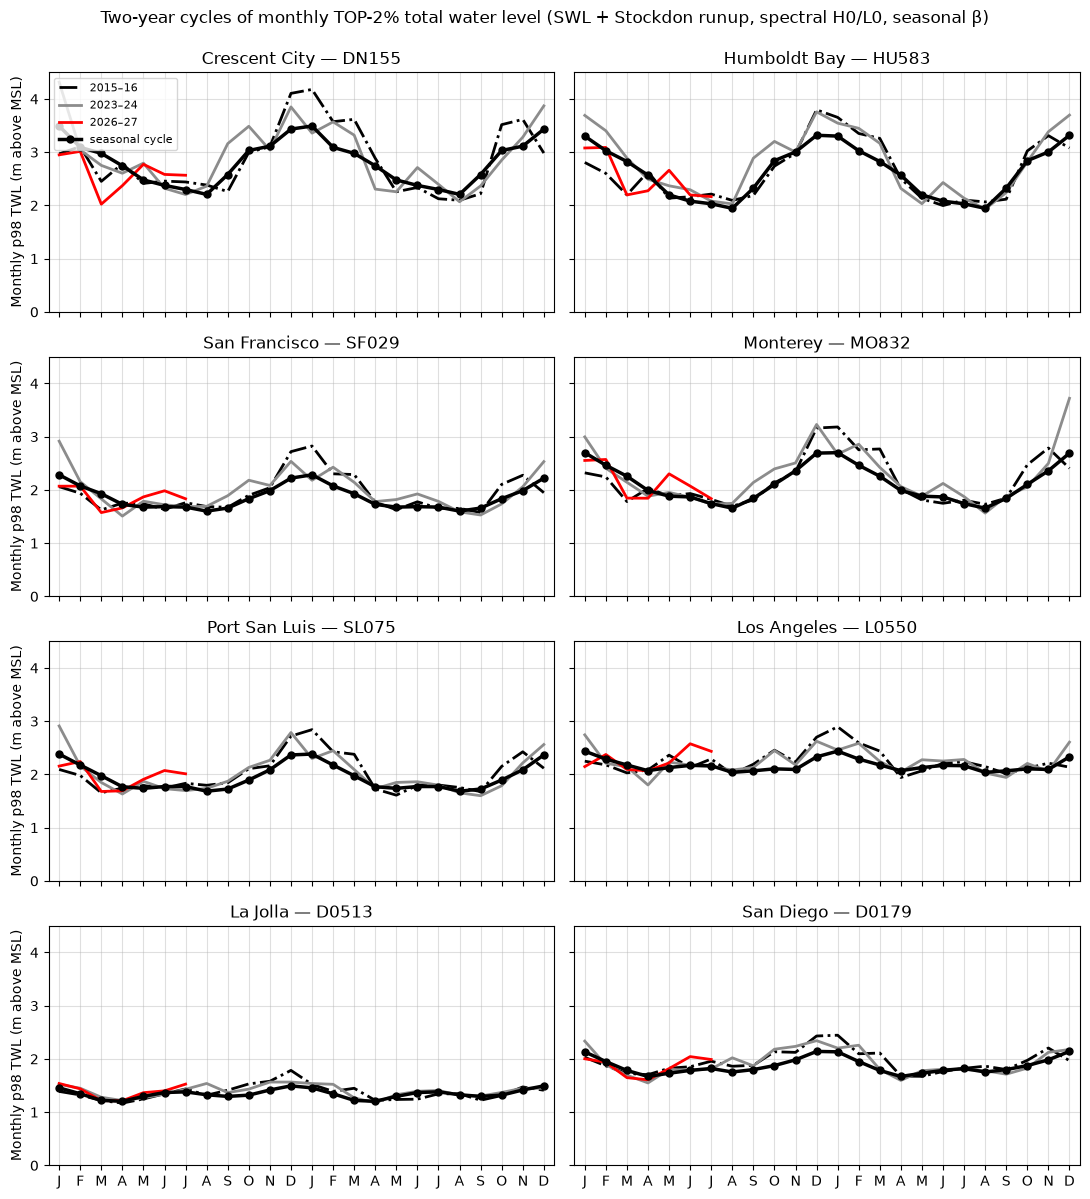

Winter (DJF) climatological p98 TWL and event peak departures (m):
  gauge          transect  DJF p98   15-16   23-24
  Crescent City     DN155     3.34   +0.69   +0.82
  Humboldt Bay      HU583     3.22   +0.48   +0.56
  San Francisco     SF029     2.19   +0.54   +0.63
  Monterey          MO832     2.62   +0.51   +1.03
  Port San Luis     SL075     2.31   +0.46   +0.53
  Los Angeles       L0550     2.35   +0.46   +0.34
  La Jolla          D0513     1.43   +0.29   +0.21
  San Diego         D0179     2.07   +0.33   +0.31


In [6]:
fig, axes = plt.subplots(4, 2, figsize=(11, 12), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, records):
    plot_two_year_cycle(ax, rec["p98_twl"], f"{rec['gauge']} — {rec['mop']}")
    ax.set_ylim(0, 4.5)
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend(handles, labels, loc="upper left", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Monthly p98 TWL (m above MSL)")
fig.suptitle("Two-year cycles of monthly TOP-2% total water level "
             "(SWL + Stockdon runup, spectral H0/L0, seasonal β)", y=0.995)
fig.tight_layout()
plt.show()

print("Winter (DJF) climatological p98 TWL and event peak departures (m):")
print(f"  {'gauge':<14} {'transect':>8} {'DJF p98':>8} {'15-16':>7} {'23-24':>7}")
for rec in records:
    clim = seasonal_climatology(rec["p98_twl"])
    djf = clim.reindex([12, 1, 2]).mean()
    deps = {}
    for onset in (2015, 2023):
        excess = two_year_window(rec["p98_twl"], onset) - np.tile(clim.to_numpy(), 2)
        deps[onset] = np.nanmax(excess) if not np.isnan(excess).all() else np.nan
    cols = [f"{deps[y]:+7.2f}" if not np.isnan(deps[y]) else f"{'n/a':>7}"
            for y in (2015, 2023)]
    print(f"  {rec['gauge']:<14} {rec['mop']:>8} {djf:8.2f} {cols[0]} {cols[1]}")

## 4. Where does the top-2% TWL come from?

Decompose the climatology at every site: the monthly p98 of TWL against the
monthly p98 of each ingredient alone. Two calibration notes before reading:

- **The still-water curve sits near 1 m everywhere and barely moves with season.**
  Zero here is each record's own mean sea level, so the p98 of hourly SWL is the
  height of the top-2% of water levels — essentially spring high tides plus a
  little surge, about a meter above MSL at every station. (NOAA's tide-page
  numbers like "MSL = 0.774 m" at La Jolla are the same level quoted above MLLW,
  a different zero — not a discrepancy.) The seasonality of the TWL extreme
  therefore comes almost entirely from runup.
- **The p98 of a sum is not the sum of the p98s** (dotted gray): the roughest
  waves must coincide with high water to raise the TWL extreme. El Niño winters
  close part of that gap by raising the floor under whatever storm arrives.

The shading answers the "who is bigger" question month by month: **red months,
runup exceeds still water; blue months, still water exceeds runup.** Watch it flip
with latitude and with slope.

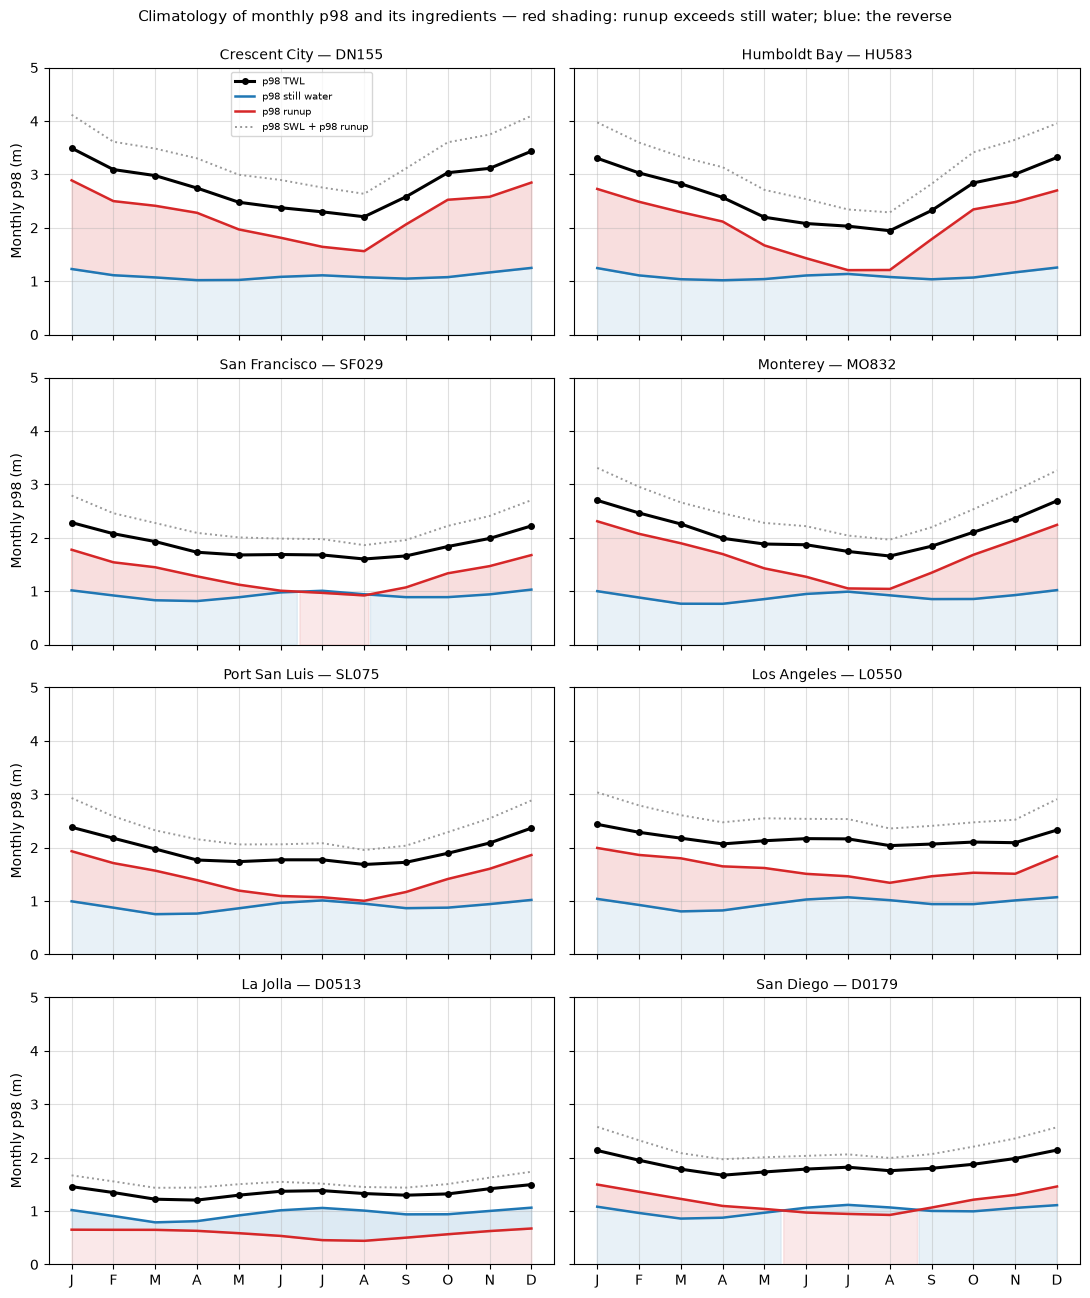

months per year in which p98 runup exceeds p98 still water:
  Crescent City  12 of 12
  Humboldt Bay   12 of 12
  San Francisco  10 of 12
  Monterey       12 of 12
  Port San Luis  12 of 12
  Los Angeles    12 of 12
  La Jolla        0 of 12
  San Diego       9 of 12


In [7]:
fig, axes = plt.subplots(4, 2, figsize=(11, 13), sharex=True, sharey=True)
months = np.arange(1, 13)
for ax, rec in zip(axes.flat, records):
    swl_c = seasonal_climatology(rec["p98_swl"]).reindex(months)
    r2_c = seasonal_climatology(rec["p98_r2"]).reindex(months)
    twl_c = seasonal_climatology(rec["p98_twl"]).reindex(months)
    # resample both curves onto a fine grid so the color switch at dominance
    # crossings is pixel-sharp (fill_between's own interpolation draws wedges)
    xf = np.linspace(1, 12, 221)
    swl_f = np.interp(xf, months, swl_c.to_numpy())
    r2_f = np.interp(xf, months, r2_c.to_numpy())
    lower_f = np.minimum(swl_f, r2_f)
    # base band: from the x axis up to the lower ingredient, in its own color
    ax.fill_between(xf, 0, lower_f, where=swl_f <= r2_f, color="tab:blue", alpha=0.10)
    ax.fill_between(xf, 0, lower_f, where=r2_f <= swl_f, color="tab:red", alpha=0.10)
    # upper band: the gap between the ingredients, colored by which is on top
    ax.fill_between(xf, swl_f, r2_f, where=r2_f >= swl_f, color="tab:red", alpha=0.15)
    ax.fill_between(xf, swl_f, r2_f, where=r2_f <= swl_f, color="tab:blue", alpha=0.15)
    ax.plot(months, twl_c, "k-o", lw=2.2, ms=4, label="p98 TWL")
    ax.plot(months, swl_c, color="tab:blue", lw=1.8, label="p98 still water")
    ax.plot(months, r2_c, color="tab:red", lw=1.8, label="p98 runup")
    ax.plot(months, swl_c + r2_c, color="0.6", ls=":", lw=1.4,
            label="p98 SWL + p98 runup")
    ax.set_xticks(months)
    ax.set_xticklabels(list("JFMAMJJASOND"))
    ax.set_ylim(0, 5)
    ax.set_title(f"{rec['gauge']} — {rec['mop']}", fontsize=10)
    ax.grid(alpha=0.4)
axes.flat[0].legend(fontsize=7, loc="upper center")
for ax in axes[:, 0]:
    ax.set_ylabel("Monthly p98 (m)")
fig.suptitle("Climatology of monthly p98 and its ingredients — "
             "red shading: runup exceeds still water; blue: the reverse",
             y=0.995, fontsize=11)
fig.tight_layout()
plt.show()

print("months per year in which p98 runup exceeds p98 still water:")
for rec in records:
    swl_c = seasonal_climatology(rec["p98_swl"]).reindex(months)
    r2_c = seasonal_climatology(rec["p98_r2"]).reindex(months)
    print(f"  {rec['gauge']:<14} {int((r2_c > swl_c).sum()):2d} of 12")

## 5. Months hide events: the winter's biggest hours

A monthly 98th percentile is set by roughly the fifteenth-largest hour of the
month. The most damaging kind of winter moment — a spring high tide arriving under
an elevated El Niño water level while a big swell is running — may contribute only
four or six hours around one or two high tides, and the statistic can miss the
event that defines the winter. So look at single hours too, at every site: the
biggest hour of each winter (October–March), and each site's ten biggest hours
decomposed into the trio that makes them dangerous. Splitting the still-water
level with a 30-day centered mean separates the **SL anomaly** (the seasonal
cycle plus El Niño — the slowly varying floor) from **tide + surge**; adding
**runup** completes the sum, exactly:

$$\mathrm{TWL} = \underbrace{\langle\mathrm{SWL}\rangle_{30d}}_{SL\ anomaly}
 + \underbrace{(\mathrm{SWL} - \langle\mathrm{SWL}\rangle_{30d})}_{tide+surge}
 + \underbrace{R_{2\%}}_{runup}$$

In the stacked panels the bars run biggest to smallest and the thick line marks
zero: segments below it are *subtracting* — an event that peaked despite a
negative anomaly, or away from peak tide. The orange cap on each bar is the
SL anomaly, so the push El Niño gave each event reads directly off the top; watch
how often the tallest bars wear one.

/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/3625428743.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sep = pd.Timedelta(min_sep)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/3625428743.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sep = pd.Timedelta(min_sep)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/3625428743.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sep = pd.Timedelta(min_sep)
/var/folders/x9/048rcc

/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/3625428743.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sep = pd.Timedelta(min_sep)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/3625428743.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sep = pd.Timedelta(min_sep)
/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_98801/3625428743.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sep = pd.Timedelta(min_sep)


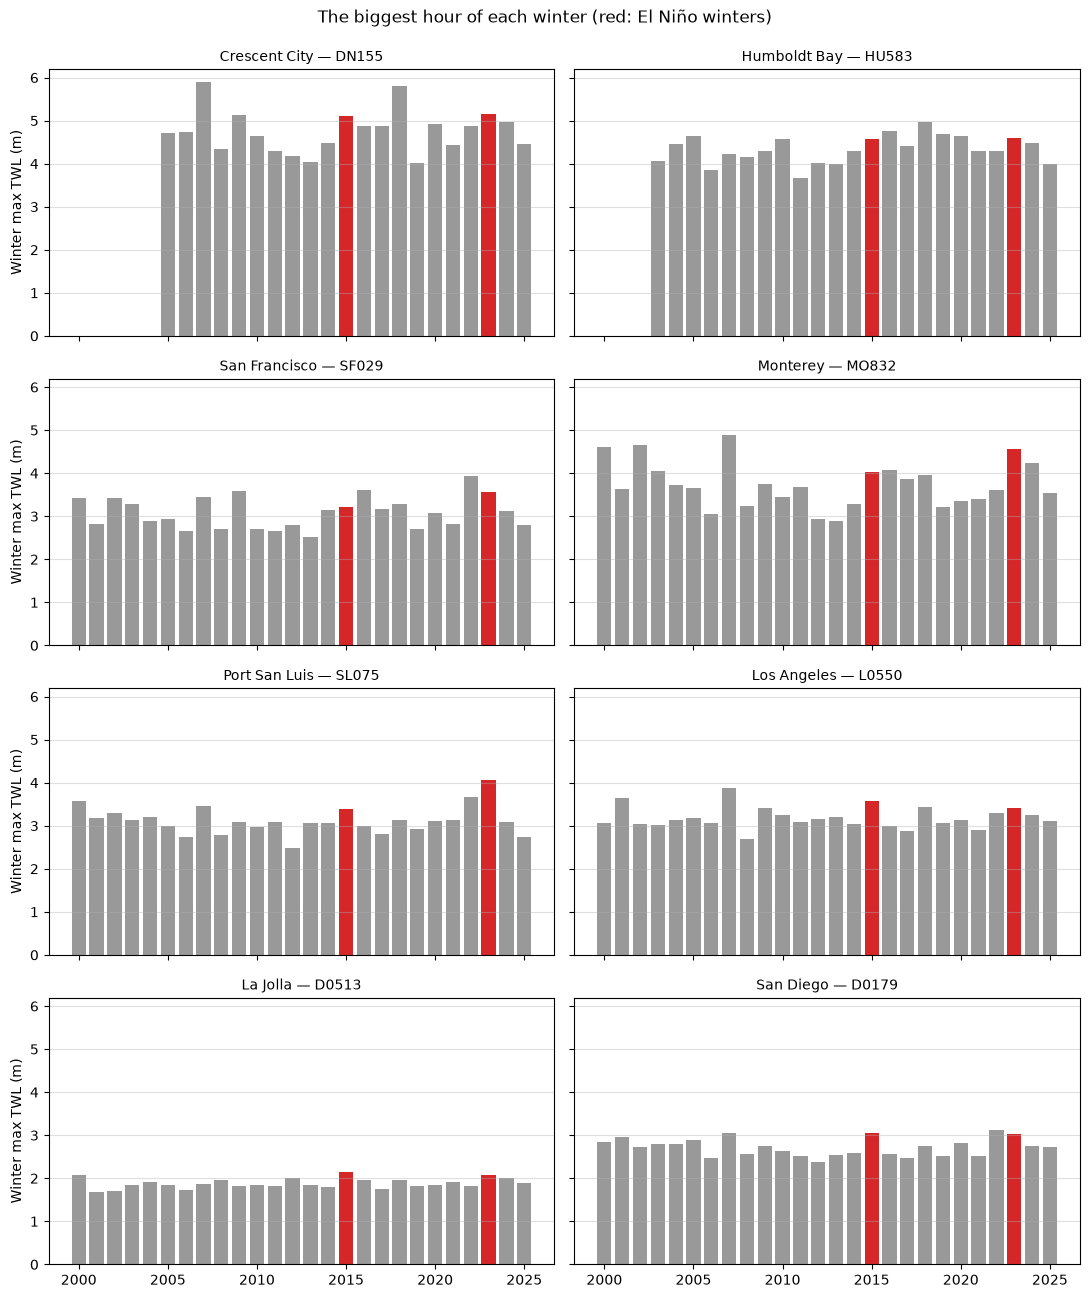

In [8]:
def winter_label(index):
    """Winter year for each timestamp: Oct-Dec -> that year, Jan-Sep -> year - 1,
    so 'winter 2015' means October 2015 through March 2016."""
    return index.year - (index.month < 10)


def top_events(twl, n=10, min_sep="3D"):
    """The n largest hourly TWL values at least min_sep apart (declustering:
    neighboring hours of the same storm should not count twice)."""
    sep = pd.Timedelta(min_sep)
    events = []
    for t, v in twl.dropna().sort_values(ascending=False).items():
        if all(abs(t - prev) > sep for prev, _ in events):
            events.append((t, v))
            if len(events) == n:
                break
    return events


# per-site slow/fast split and event census, reused by the two figures below
for rec in records:
    f = rec["frame"]
    slow = f["swl"].rolling(720, center=True, min_periods=360).mean()
    label = winter_label(f.index)
    wmax = f["twl"].groupby(label).max()
    wmax[f["twl"].groupby(label).count() < 2000] = np.nan
    rec["winter_max"] = wmax.loc[2000:2025]
    rec["events"] = pd.DataFrame(
        [{"when": t, "TWL": v, "SL anomaly": slow[t],
          "tide + surge": f.loc[t, "swl"] - slow[t], "runup": f.loc[t, "r2"]}
         for t, v in top_events(f["twl"], n=10)]
    ).set_index("when").sort_values("TWL", ascending=False)   # biggest first

fig, axes = plt.subplots(4, 2, figsize=(11, 13), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, records):
    wmax = rec["winter_max"]
    colors = ["tab:red" if y in (2015, 2023) else "0.6" for y in wmax.index]
    ax.bar(wmax.index, wmax, color=colors)
    ax.set_title(f"{rec['gauge']} — {rec['mop']}", fontsize=10)
    ax.grid(alpha=0.4, axis="y")
for ax in axes[:, 0]:
    ax.set_ylabel("Winter max TWL (m)")
fig.suptitle("The biggest hour of each winter (red: El Niño winters)", y=0.995)
fig.tight_layout()
plt.show()

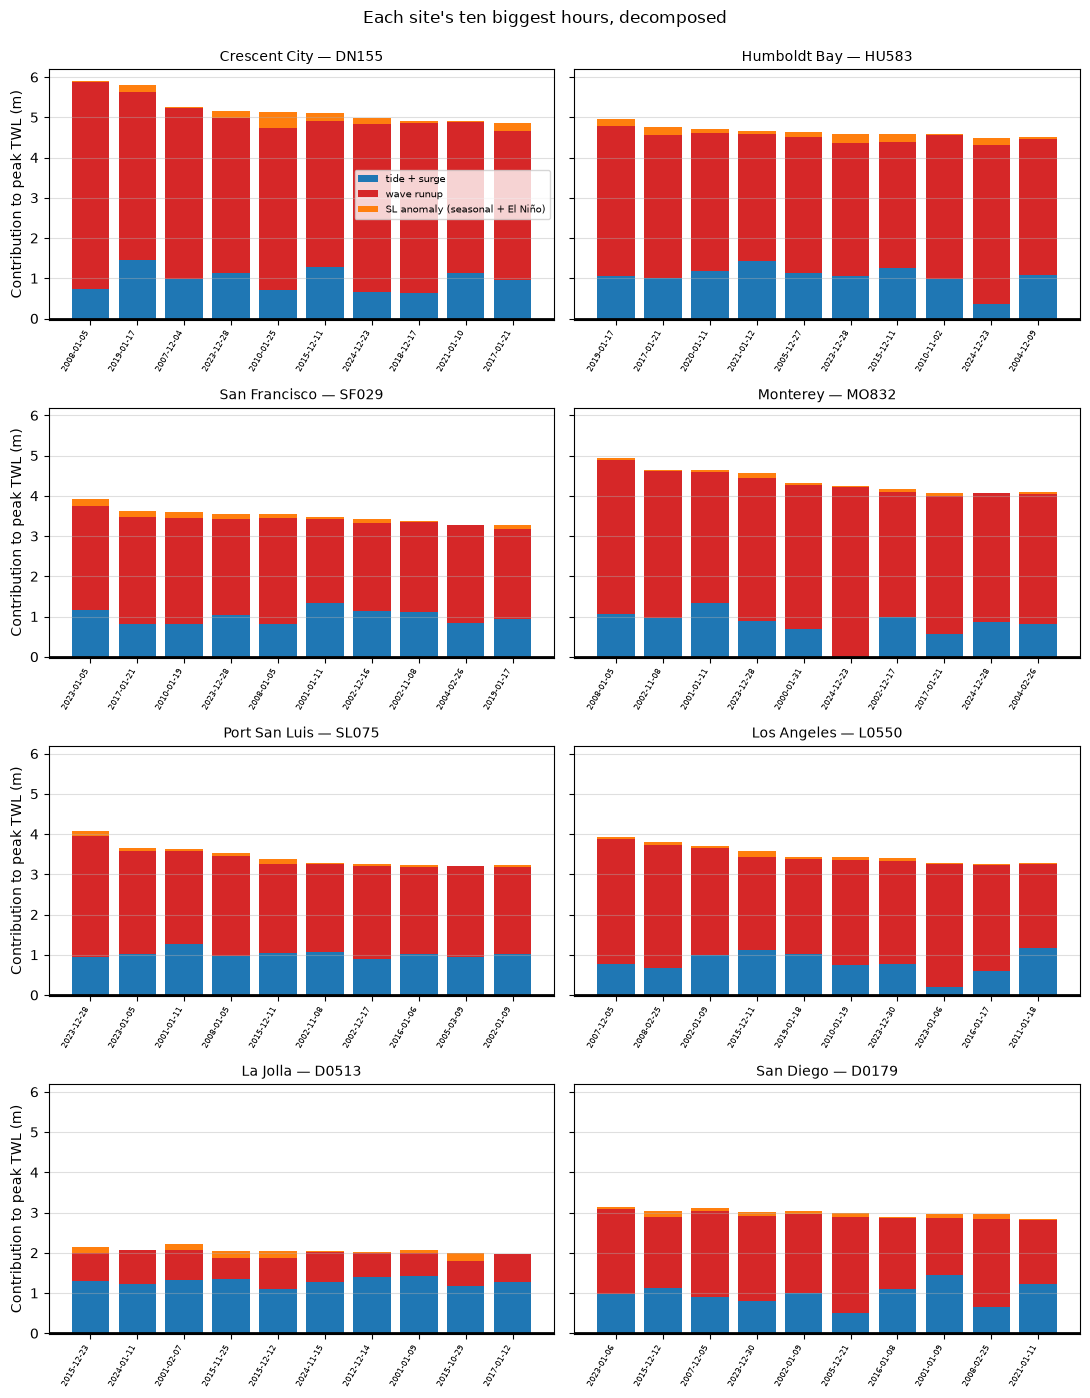

each site's single biggest hour:
gauge            top hour (UTC)    TWL  SL anom  tide+surge  runup  winter
Crescent City  2008-01-05 08:00   5.90     0.03        0.74   5.14    2007
Humboldt Bay   2019-01-17 17:00   4.96     0.19        1.06   3.72    2018
San Francisco  2023-01-05 18:00   3.93     0.18        1.17   2.58    2022
Monterey       2008-01-05 16:00   4.89    -0.06        1.06   3.90    2007
Port San Luis  2023-12-28 18:00   4.07     0.11        0.95   3.01    2023
Los Angeles    2007-12-05 13:00   3.87    -0.05        0.76   3.16    2007
La Jolla       2015-12-23 15:00   2.14     0.14        1.29   0.70    2015
San Diego      2023-01-06 16:00   3.13     0.05        0.97   2.11    2022


In [9]:
fig, axes = plt.subplots(4, 2, figsize=(11, 14), sharey=True)
for ax, rec in zip(axes.flat, records):
    ev = rec["events"]
    # stack order: tide+surge, then runup, with the SL anomaly capping the bar
    # so the El Niño push sits visibly on top
    bottom = np.zeros(len(ev))
    for part, display, color in [
            ("tide + surge", "tide + surge", "tab:blue"),
            ("runup", "wave runup", "tab:red"),
            ("SL anomaly", "SL anomaly (seasonal + El Niño)", "tab:orange")]:
        ax.bar(range(len(ev)), ev[part], bottom=bottom, color=color,
               label=display if ax is axes.flat[0] else None)
        bottom += ev[part].to_numpy()
    ax.axhline(0, color="k", lw=2)   # thick zero: bars below are subtracting
    ax.set_xticks(range(len(ev)))
    ax.set_xticklabels([f"{t:%Y-%m-%d}" for t in ev.index], rotation=60,
                       ha="right", fontsize=6)
    ax.set_title(f"{rec['gauge']} — {rec['mop']}", fontsize=10)
    ax.grid(alpha=0.4, axis="y")
axes.flat[0].legend(fontsize=7)
for ax in axes[:, 0]:
    ax.set_ylabel("Contribution to peak TWL (m)")
fig.suptitle("Each site's ten biggest hours, decomposed", y=0.995)
fig.tight_layout()
plt.show()

print("each site's single biggest hour:")
print(f"{'gauge':<14} {'top hour (UTC)':>16} {'TWL':>6} {'SL anom':>8} "
      f"{'tide+surge':>11} {'runup':>6} {'winter':>7}")
for rec in records:
    t = rec["events"]["TWL"].idxmax()
    ev = rec["events"].loc[t]
    print(f"{rec['gauge']:<14} {t:%Y-%m-%d %H:00} {ev['TWL']:6.2f} "
          f"{ev['SL anomaly']:8.2f} {ev['tide + surge']:11.2f} {ev['runup']:6.2f} "
          f"{winter_label(pd.DatetimeIndex([t]))[0]:>7}")

## 6. How much do the method choices matter?

The slope is the softest number in the whole chain, so test it at every site:
winter (DJF) climatological p98 TWL with the seasonal satellite fit used above,
against fixed slopes across the plausible beach range. A second check at
La Jolla compares the spectral deep-water wave input against the shortcut of
feeding the 10-m bulk Hs and Tp straight into the formula.

In [10]:
print(f"{'gauge':<14} {'transect':>8} {'seasonal fit':>13} {'β=0.02':>8} "
      f"{'β=0.05':>8} {'β=0.10':>8}")
for rec in records:
    f = rec["frame"]
    cols = [seasonal_climatology(monthly_p98(f["twl"])).reindex([12, 1, 2]).mean()]
    for beta in (0.02, 0.05, 0.10):
        twl_v = f["swl"] + stockdon_r2(f["h0"], f["l0"], beta)
        cols.append(seasonal_climatology(monthly_p98(twl_v)).reindex([12, 1, 2]).mean())
    print(f"{rec['gauge']:<14} {rec['mop']:>8} {cols[0]:12.2f}m "
          f"{cols[1]:7.2f}m {cols[2]:7.2f}m {cols[3]:7.2f}m")

# wave-input check at one site: spectral deep-water H0/L0 vs the 10-m bulk shortcut
lj = next(r for r in records if r["gauge"] == "La Jolla")
with xr.open_dataset(MOP_RAW / "D0513_hindcast.nc") as ds:
    ds = ds.swap_dims({"obs": "time"})
    bad = ds["waveFlagPrimary"].to_series() != 1
    hs10 = ds["waveHs"].to_series()
    tp10 = ds["waveTp"].to_series()
    hs10[bad], tp10[bad] = np.nan, np.nan
l0_bulk = GRAV * tp10 ** 2 / (2 * np.pi)
bulk = (lj["frame"]["swl"] + stockdon_r2(hs10, l0_bulk, 0.05)).dropna()
spec = lj["frame"]["swl"] + stockdon_r2(lj["frame"]["h0"], lj["frame"]["l0"], 0.05)
print(f"\nLa Jolla wave-input check (both at fixed β=0.05):")
print(f"  bulk 10-m Hs/Tp shortcut:  DJF p98 TWL = "
      f"{seasonal_climatology(monthly_p98(bulk)).reindex([12, 1, 2]).mean():.2f} m")
print(f"  spectral deep-water H0/L0: DJF p98 TWL = "
      f"{seasonal_climatology(monthly_p98(spec)).reindex([12, 1, 2]).mean():.2f} m")

gauge          transect  seasonal fit   β=0.02   β=0.05   β=0.10
Crescent City     DN155         3.34m    2.37m    2.88m    3.97m
Humboldt Bay      HU583         3.22m    2.51m    3.08m    4.29m


San Francisco     SF029         2.19m    2.31m    2.91m    4.17m
Monterey          MO832         2.62m    2.04m    2.53m    3.58m
Port San Luis     SL075         2.31m    1.99m    2.44m    3.42m


Los Angeles       L0550         2.35m    1.66m    1.94m    2.57m
La Jolla          D0513         1.43m    1.36m    1.51m    1.81m
San Diego         D0179         2.07m    1.81m    2.13m    2.82m



La Jolla wave-input check (both at fixed β=0.05):
  bulk 10-m Hs/Tp shortcut:  DJF p98 TWL = 1.50 m
  spectral deep-water H0/L0: DJF p98 TWL = 1.51 m


The slope dominates at every site: tens of centimeters across realistic β,
comparable to the entire El Niño signal, which is why the group went to the trouble
of fitting slopes from satellite shorelines instead of assuming one. The wave-input
choice matters far less. Treat every absolute number in this notebook as
conditional on β; the *relative* seasonal and event structure is much sturdier.

## 7. What the stack says, and your assignment

- **The north stacks; the south staggers — and slope amplifies the stack.**
  North of San Francisco the seasonal maxima of still-water level and waves land
  together in December–January and El Niño amplifies both at once, which is why the
  event departures peak from Monterey northward. Slope then sets the amplitude:
  steep Crescent Beach (β ≈ 0.08) and the Samoa spit top the winter table at over
  3 m, while dissipative Ocean Beach (β ≈ 0.01) converts the coast's biggest waves
  into the mildest runup north of Point Conception. In the south the seasonal sea
  level peak (September) is months out of phase with the wave peak; El Niño
  partially re-synchronizes them by holding water levels high through the winter.
- **Events differ by ingredient.** 2015–16 raised the water level and the waves;
  2023–24 barely raised the water but threw the biggest single-month wave extremes of
  the record at the central coast. Their TWL signatures differ accordingly — check
  which appears strongest at each latitude in the grid.
- **2026–27 so far** exists only through June 2026 here, because the hourly gauge
  files lag. Notebook 11 pulled the recent months from NOAA CO-OPS; porting that
  extension to hourly data is the natural upgrade to this notebook.

**In your groups:** build the TWL analysis for your station. Decide your transect
(notebook 12's maps), defend your slope (satellite fit, borrowed, or assumed), and
report your station's top-2% TWL climatology and event departures in meters. If your
gauge is research-quality only, say what you can and cannot conclude about 2023–24
and 2026–27.

Questions worth arguing about:

1. Stockdon et al. give a separate formula for dissipative beaches
   ($R_{2\%} = 0.043\sqrt{H_0 L_0}$ when the Iribarren number is below 0.3). Ocean
   Beach's fitted β ≈ 0.01 puts it squarely in that regime — would switching raise or
   lower its curves, and by roughly how much in a 3-m, 15-s winter swell?
2. Take your site's top event from section 5 and rerun the clock: if the same storm
   had arrived three days later, which of the three ingredients change and which do
   not? What does that say about forecasting damage versus forecasting waves?
3. From 26 winters of data, how would you estimate the total water level with a
   1-in-50-winter return period? What makes that extrapolation harder than it
   looks, and what does one El Niño event do to it?

## Data provenance

- Still-water level: UHSLC hourly tide gauge files (fast-delivery archive for
  `h551`, `h554`, `h556`, `h569`; research-quality archive for `h555a`, `h565a`,
  `h567a`, `h576a`), retrieved 2026-08-13 from
  `https://uhslc.soest.hawaii.edu/data/netcdf/`; Caldwell, Merrifield, and Thompson
  (2015), doi:10.7289/V5V40S7W. Extended to the present with NOAA CO-OPS verified
  hourly water levels plus a preliminary 6-minute bridge (`api.tidesandcurrents.
  noaa.gov`), datum-aligned per site by median offset over the shared hours;
  completed years cached in `data/code-downloaded/coops_hourly/`.
- Waves: CDIP MOP v1.1 hourly frequency spectra (`waveEnergyDensity`), NCSS as in
  notebook 12; O'Reilly et al. (2016), doi:10.1016/j.coasteng.2016.06.005.
- Runup: Stockdon, H. F., R. A. Holman, P. A. Howd, and A. H. Sallenger (2006),
  *Empirical parameterization of setup, swash, and runup*, Coastal Engineering,
  53(7), 573–588, doi:10.1016/j.coastaleng.2005.12.005. Implementation ported from
  M. Merrifield's `MopSusheelStockdon.m` (reefbreak, `group/BOR/Runup/`), including
  the Wu & Thornton (1986) dispersion solver (J. Waterway, Port, Coastal, Ocean
  Eng., 112(4), 536–540).
- Beach slopes: seasonal foreshore-slope sinusoids fit to CoastSat satellite
  shorelines (S. Adusumilli's analysis; `VosTransects-filt.mat` on reefbreak,
  exported via MATLAB to `data/code-downloaded/vost_seasonal_slopes.csv` together
  with the MOP name-to-number table from `group/MOPS/MopTableUTM.mat`).
- All raw files live under `data/raw/` and stay out of Git per the course data
  contract; the fetch cells regenerate them from the providers. The two slope CSVs
  require reefbreak + MATLAB to regenerate — keep them.